In [ ]:
!pip install ucimlrepo
!pip install -U scikeras scikit-learn
!pip -q install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 42.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


AIR QUALITY --> REGRESSION

TRAVEL REVIEWS --> CLUSTERING

F1 CARS --> CLASSIFICATION

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scikeras.wrappers import KerasRegressor
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score
)
from scipy.optimize import linear_sum_assignment

import kagglehub, os
from sklearn.preprocessing import label_binarize
from tensorflow.keras import layers, models



AIR QUALITY --> REGRESSION

In [ ]:

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
X = air_quality.data.features

# print the metadata
print(air_quality.metadata)
print(air_quality.variables)

X = X.replace(-200, np.nan)
X = X.dropna(thresh=int(0.7 * X.shape[1]))

# Extract the target variable 'CO(GT)' from X
y = X["CO(GT)"]

# Drop 'CO(GT)', 'Date', and 'Time' from X
X = X.drop(columns=["CO(GT)", "Date", "Time"], errors="ignore")

# Drop rows where y is NaN (and corresponding X rows)
# Create a boolean mask for non-NaN values in y
non_nan_mask = ~y.isna()
X = X[non_nan_mask]
y = y[non_nan_mask]

# Fill remaining NaN values in X with the mean of their respective columns
X = X.fillna(X.mean())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split dei dataset in validation, test e training set
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# static dimention for reduction
latent_dim = 10

# pca reduction
pca = PCA(n_components=latent_dim)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)


input_dim = X_train.shape[1]

# autoencoder reduction
inp = Input(shape=(input_dim,))
enc = Dense(32, activation="relu")(inp)
enc = Dense(latent_dim, activation="relu")(enc)

dec = Dense(32, activation="relu")(enc)
dec = Dense(input_dim, activation="linear")(dec)

autoencoder = Model(inp, dec)
encoder = Model(inp, enc)

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32
)

X_train_ae = encoder.predict(X_train)
X_val_ae = encoder.predict(X_val)
X_test_ae = encoder.predict(X_test)


{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [ ]:
def build_fnn_model(input_dim, hidden_layers=2, units=64, dropout=0.0, lr=1e-3):
    """
    Build Feedforward Neural Network for regression.
    Hyperparameters are exposed so RandomizedSearchCV can tune them.
    """
    model = Sequential()
    model.add(Dense(units, activation="relu", input_shape=(input_dim,)))

    for _ in range(hidden_layers - 1):
        if dropout > 0:
            model.add(Dropout(dropout))
        model.add(Dense(units, activation="relu"))

    model.add(Dense(1, activation="linear"))  # regression output

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model

def train_fnn_with_cv(X_tr, y_tr, X_val, y_val, X_te, y_te, tag):
    """
    1) Tune hyperparameters with CV on training set only
    2) Train final model on train+val with best hyperparameters
    3) Evaluate on test
    """
    start_time = time.perf_counter()

    # sklearn-compatible wrapper around Keras model
    reg = KerasRegressor(
        model=build_fnn_model,
        model__input_dim=X_tr.shape[1],
        verbose=0,
        warm_start=False,
        loss="mse"
    )

    # CV strategy (3-fold)
    cv = KFold(n_splits=3, shuffle=True, random_state=42)

    # Hyperparameter search space
    param_dist = {
        "model__hidden_layers": [1, 2, 3],
        "model__units": [32, 64, 128],
        "model__dropout": [0.0, 0.1, 0.2, 0.3],
        "model__lr": [1e-4, 3e-4, 1e-3, 3e-3],
        "batch_size": [16, 32, 64],
        "epochs": [60, 100]
    }

    # Randomized search (optimize negative MSE)
    search = RandomizedSearchCV(
        reg,
        param_distributions=param_dist,
        n_iter=10,
        scoring="neg_mean_squared_error",
        cv=cv,
        random_state=42,
        n_jobs=1,
        refit=True
    )

    # Run CV tuning on training set only
    search.fit(X_tr, y_tr)

    best_params = search.best_params_
    best_cv_mse = -search.best_score_

    # Train final model on train+val
    X_trainval = np.vstack([X_tr, X_val])
    y_trainval = np.concatenate([y_tr, y_val])



    final_model = build_fnn_model(
        input_dim=X_trainval.shape[1],
        hidden_layers=best_params["model__hidden_layers"],
        units=best_params["model__units"],
        dropout=best_params["model__dropout"],
        lr=best_params["model__lr"]
    )


    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    history = final_model.fit(
        X_trainval, y_trainval,
        validation_split=0.15,
        epochs=best_params["epochs"],
        batch_size=best_params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate on test set
    y_pred = final_model.predict(X_te).reshape(-1)

    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)

    elapsed_time = time.perf_counter() - start_time

    print("\n==============================")
    print(tag)
    print("Best CV MSE:", best_cv_mse)
    print("Best params:", best_params)
    print("TEST  MSE :", mse)
    print("TEST RMSE :", rmse)
    print("TEST  MAE :", mae)
    print("TEST   R2 :", r2)
    print(f"Training time: {elapsed_time:.2f} seconds")


    return final_model, history.history, {
        "best_cv_mse": best_cv_mse,
        "best_params": best_params,
        "test_mse": mse,
        "test_rmse": rmse,
        "test_mae": mae,
        "test_r2": r2,
        "training_time_sec": elapsed_time
    }



# Train the 3 required models
y_train_np = np.array(y_train, dtype=float)
y_val_np = np.array(y_val, dtype=float)
y_test_np = np.array(y_test, dtype=float)

# 1) Original features
model_orig, hist_orig, metrics_orig = train_fnn_with_cv(
    X_train, y_train_np, X_val, y_val_np, X_test, y_test_np,
    tag="FNN Regression (Original Features)"
)

# 2) PCA reduced
model_pca, hist_pca, metrics_pca = train_fnn_with_cv(
    X_train_pca, y_train_np, X_val_pca, y_val_np, X_test_pca, y_test_np,
    tag="FNN Regression (PCA Reduced)"
)

# 3) Autoencoder reduced
model_ae, hist_ae, metrics_ae = train_fnn_with_cv(
    X_train_ae, y_train_np, X_val_ae, y_val_np, X_test_ae, y_test_np,
    tag="FNN Regression (Autoencoder Reduced)"
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

FNN Regression (Original Features)
Best CV MSE: 0.16043579985423845
Best params: {'model__units': 128, 'model__lr': 0.003, 'model__hidden_layers': 2, 'model__dropout': 0.1, 'epochs': 60, 'batch_size': 64}
TEST  MSE : 0.1395701006456218
TEST RMSE : 0.37359081980908176
TEST  MAE : 0.2337131391960566
TEST   R2 : 0.9303746119652201
Training time: 728.60 seconds


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

FNN Regression (PCA Reduced)
Best CV MSE: 0.1637460787247006
Best params: {'model__units': 128, 'model__lr': 0.0003, 'model__hidden_layers': 2, 'model__dropout': 0.1, 'epochs': 100, 'batch_size': 32}
TEST  MSE : 0.14615929494087837
TEST RMSE : 0.3823078536217617
TEST  MAE : 0.2331204371097516
TEST   R2 : 0.9270875525769872
Training time: 740.92 seconds


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

FNN Regression (Autoencoder Reduced)
Best CV MSE: 0.1740486865327884
Best params: {'model__units': 128, 'model__lr': 0.0003, 'model__hidden_layers': 2, 'model__dropout': 0.1, 'epochs': 100, 'batch_size': 32}
TEST  MSE : 0.1631552633007841
TEST RMSE : 0.403924823823424
TEST  MAE : 0.2520919377785413
TEST   R2 : 0.9186090110655077
Training time: 735.54 seconds



=== COMPARATIVE ANALYSIS: REGRESSION METRICS ===
                     test_mse test_rmse  test_mae   test_r2
Original Features     0.13957  0.373591  0.233713  0.930375
PCA Reduced          0.146159  0.382308   0.23312  0.927088
Autoencoder Reduced  0.163155  0.403925  0.252092  0.918609


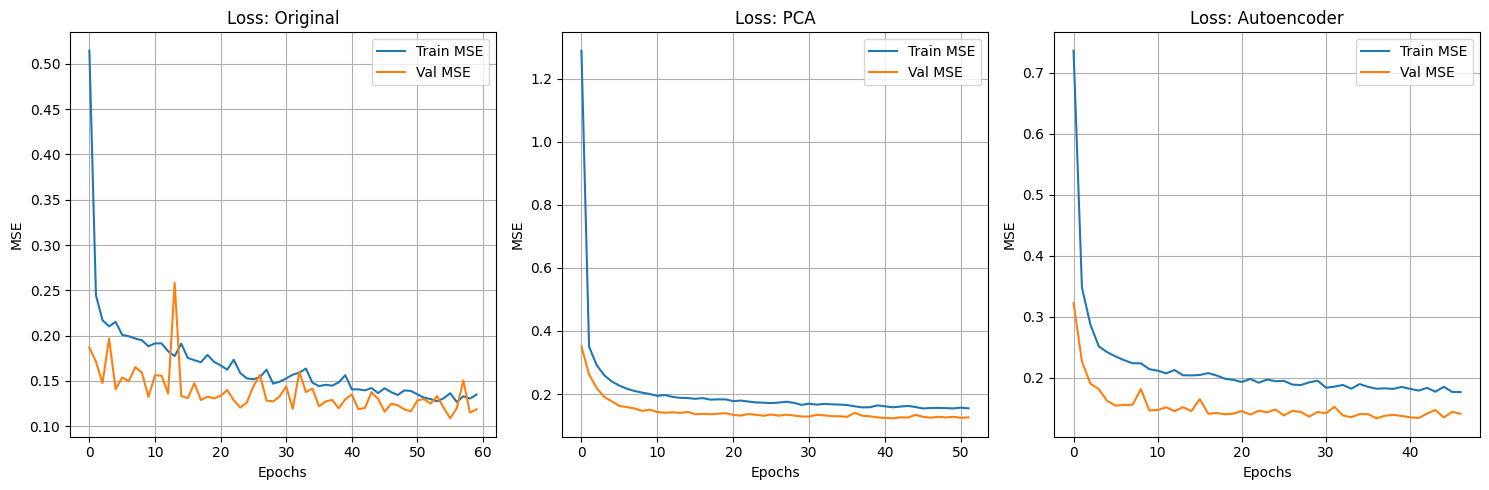

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


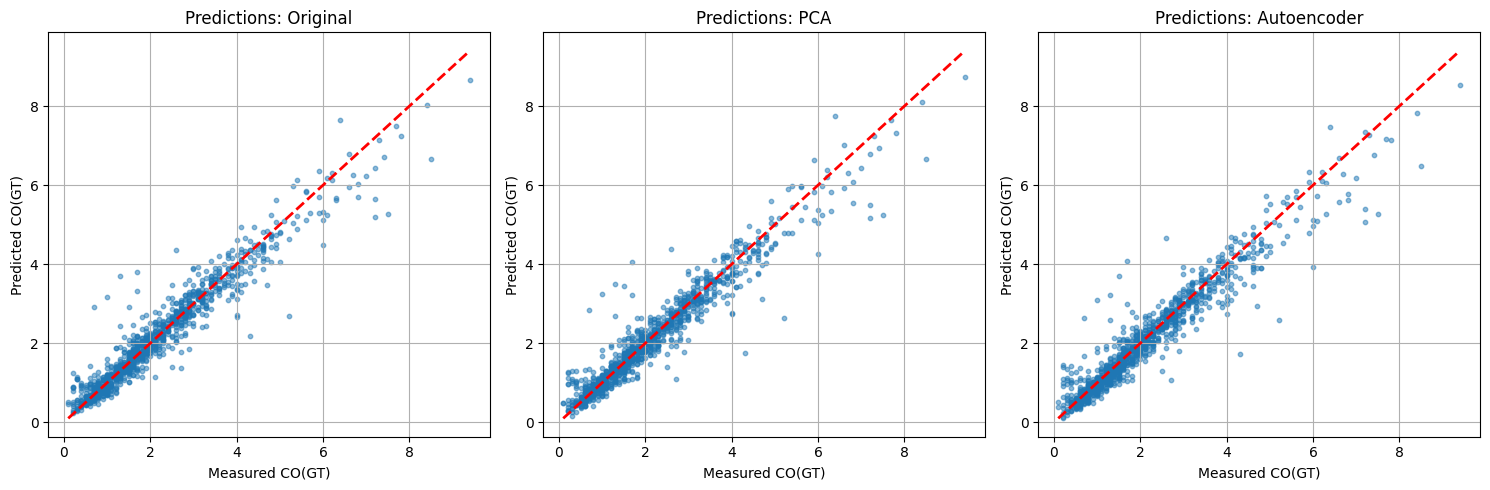

In [ ]:
# Creazione di un DataFrame per confrontare i risultati
comparison_data = {
    "Original Features": metrics_orig,
    "PCA Reduced": metrics_pca,
    "Autoencoder Reduced": metrics_ae
}

df_metrics = pd.DataFrame(comparison_data).T
# Print the metrics and draw the plots
print("\n=== COMPARATIVE ANALYSIS: REGRESSION METRICS ===")
print(df_metrics[["test_mse", "test_rmse", "test_mae", "test_r2"]].round(4))

def plot_all_histories(histories, tags):
    plt.figure(figsize=(15, 5))

    for i, (hist, tag) in enumerate(zip(histories, tags)):
        plt.subplot(1, 3, i+1)
        plt.plot(hist['loss'], label='Train MSE')
        plt.plot(hist['val_loss'], label='Val MSE')
        plt.title(f'Loss: {tag}')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Esecuzione del plot per i tre modelli
plot_all_histories(
    [hist_orig, hist_pca, hist_ae],
    ["Original", "PCA", "Autoencoder"]
)

def plot_predictions(models, datasets, y_true, tags):
    plt.figure(figsize=(15, 5))

    for i, (model, X_te, tag) in enumerate(zip(models, datasets, tags)):
        y_pred = model.predict(X_te).reshape(-1)

        plt.subplot(1, 3, i+1)
        plt.scatter(y_true, y_pred, alpha=0.5, s=10)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
        plt.title(f'Predictions: {tag}')
        plt.xlabel('Measured CO(GT)')
        plt.ylabel('Predicted CO(GT)')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Esecuzione del plot
plot_predictions(
    [model_orig, model_pca, model_ae],
    [X_test, X_test_pca, X_test_ae],
    y_test_np,
    ["Original", "PCA", "Autoencoder"]
)

SECOND DB TRAVEL REVIEWS --> CLUSTERING

In [ ]:


# Fetch dataset (Travel Reviews)
travel_reviews = fetch_ucirepo(id=484)
X_raw = travel_reviews.data.features
y_true = travel_reviews.data.targets # Opzionale per validazione esterna


# Preprocessing specifico per dati numerici

# Gestione dei missing values
X_cleaned = X_raw.fillna(X_raw.mean())

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cleaned)

# Split per l'addestramento dell'Autoencoder
X_train, X_temp = train_test_split(X_scaled, test_size=0.3, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)


# static dimention for reduction
latent_dim = 5

# PCA reduction
pca = PCA(n_components=latent_dim, random_state=42)
X_pca_full = pca.fit_transform(X_scaled)

# AUTOENCODER reduction
input_dim = X_train.shape[1]
inp = Input(shape=(input_dim,))
enc = Dense(16, activation="relu")(inp)
enc = Dense(latent_dim, activation="relu")(enc) # Bottleneck
dec = Dense(16, activation="relu")(enc)
dec = Dense(input_dim, activation="linear")(dec)

autoencoder = Model(inp, dec)
encoder = Model(inp, enc)
autoencoder.compile(optimizer="adam", loss="mse")

# Addestramento silenzioso
autoencoder.fit(X_train, X_train, validation_data=(X_val, X_val),
                epochs=50, batch_size=32, verbose=0)

# Rappresentazione ridotta per il clustering
X_ae_full = encoder.predict(X_scaled, verbose=0)

print(f"Preprocessing completato. Dimensioni: Originale {X_scaled.shape}, Ridotto {X_pca_full.shape}")

Preprocessing completato. Dimensioni: Originale (980, 10), Ridotto (980, 5)


In [ ]:
def tune_kmeans(X, k_values, tag, random_state=42):
    """
    Choose best K using internal clustering metrics.
    Returns best fitted model + metrics table (list of dicts).
    """
    results = []
    best_model = None
    best_k = None
    best_score = -np.inf  # we will maximize silhouette

    # start timer for timing measurements
    start_time = time.perf_counter()

    for k in k_values:
        # KMeans model
        model = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=random_state
        )

        labels = model.fit_predict(X)

        # Silhouette
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)          # lower is better
        ch = calinski_harabasz_score(X, labels)       # higher is better
        inertia = model.inertia_                      # lower is better

        results.append({
            "k": k,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "inertia": inertia
        })

        # Choose best by silhouette
        if sil > best_score:
            best_score = sil
            best_k = k
            best_model = model

    # stop timer
    elapsed_time = time.perf_counter() - start_time

    # printing results
    print("\n==============================")
    print(tag)
    print("Best k:", best_k)
    print("Best silhouette:", best_score)
    print(f"Tuning + fit time: {elapsed_time:.2f} seconds")

    return best_model, results, {
        "best_k": best_k,
        "best_silhouette": best_score,
        "training_time_sec": elapsed_time
    }

#tuning the 3 models
k_values = [2, 3, 4, 5, 6, 7, 8]

# 1) Original features
kmeans_orig, results_orig, metrics_orig = tune_kmeans(
    X_scaled,
    k_values=k_values,
    tag="K-Means Clustering (Original Features)"
)

# 2) PCA reduced
kmeans_pca, results_pca, metrics_pca = tune_kmeans(
    X_pca_full,
    k_values=k_values,
    tag="K-Means Clustering (PCA Reduced)"
)

# 3) Autoencoder reduced
kmeans_ae, results_ae, metrics_ae = tune_kmeans(
    X_ae_full,
    k_values=k_values,
    tag="K-Means Clustering (Autoencoder Reduced)"
)



K-Means Clustering (Original Features)
Best k: 2
Best silhouette: 0.21315362778467906
Tuning + fit time: 1.55 seconds

K-Means Clustering (PCA Reduced)
Best k: 2
Best silhouette: 0.2715698369846399
Tuning + fit time: 1.16 seconds

K-Means Clustering (Autoencoder Reduced)
Best k: 3
Best silhouette: 0.3457231819629669
Tuning + fit time: 1.27 seconds



Original - K tuning summary (best by silhouette)
Best k: 2
Best silhouette: 0.21315362778467906


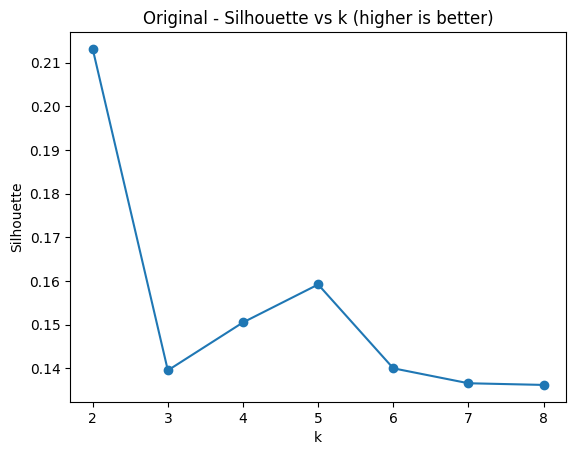

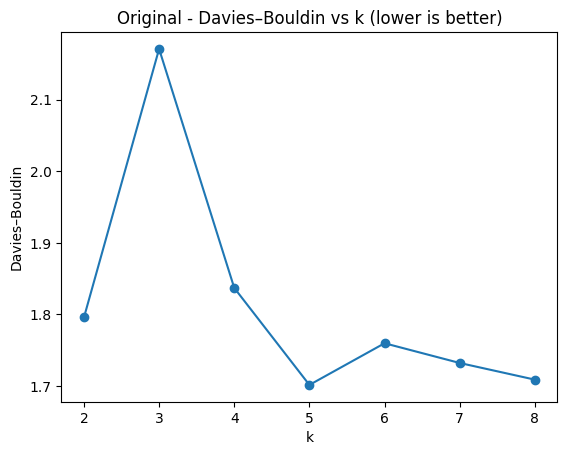

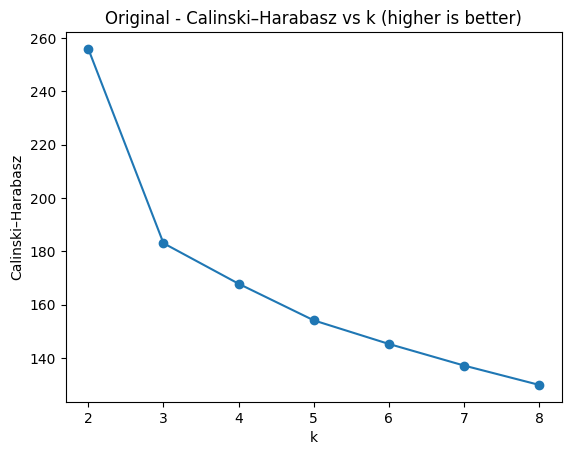


PCA - K tuning summary (best by silhouette)
Best k: 2
Best silhouette: 0.2715698369846399


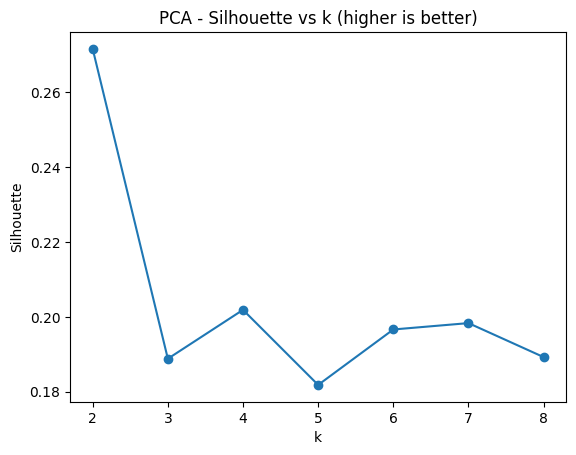

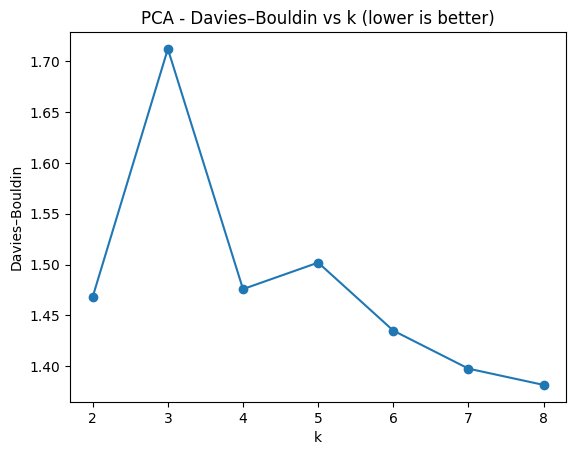

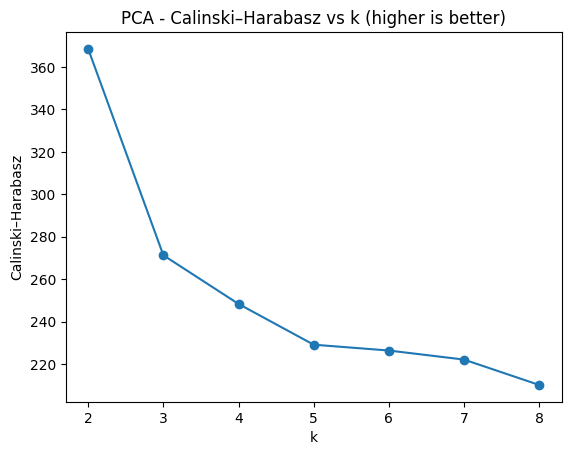


AE - K tuning summary (best by silhouette)
Best k: 3
Best silhouette: 0.3457231819629669


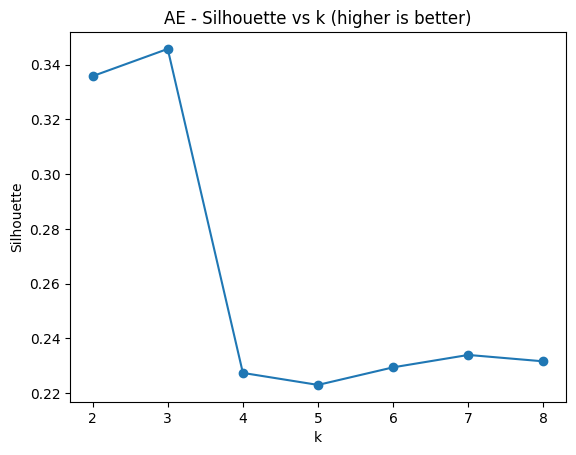

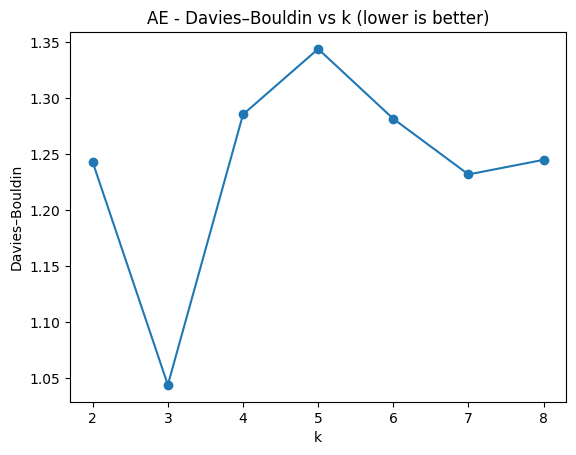

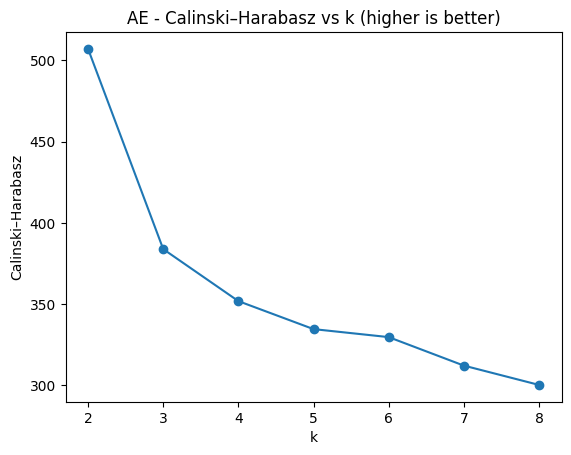


Original final
Silhouette Score     : 0.21315362778467906
Davies–Bouldin Score : 1.795668987019947
Calinski–Harabasz    : 255.9265179548312
Training time: 0.02 seconds

PCA final
Silhouette Score     : 0.2715698369846399
Davies–Bouldin Score : 1.46824433368258
Calinski–Harabasz    : 368.4357987188848
Training time: 0.02 seconds

AE final
Silhouette Score     : 0.3457231819629669
Davies–Bouldin Score : 1.0442074166901925
Calinski–Harabasz    : 383.82118425780624
Training time: 0.03 seconds


{'silhouette': 0.3457231819629669,
 'davies_bouldin': 1.0442074166901925,
 'calinski_harabasz': 383.82118425780624,
 'training_time_sec': 0.025841919999976426}

In [ ]:

# CLUSTERING EVALUATION (K-Means)
# Metrics + Plots:

# K-Means training
def fit_kmeans(X, k, random_state=42, n_init=10):
    start = time.perf_counter()
    km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    labels = km.fit_predict(X)
    elapsed = time.perf_counter() - start
    return km, labels, elapsed



# Internal clustering metrics
def clustering_internal_metrics(X, cluster_labels, training_time_sec=None, tag=""):
    sil = silhouette_score(X, cluster_labels)
    db = davies_bouldin_score(X, cluster_labels)       # lower is better
    ch = calinski_harabasz_score(X, cluster_labels)    # higher is better

    print("\n==============================")
    print(tag)
    print("Silhouette Score     :", sil)
    print("Davies–Bouldin Score :", db)
    print("Calinski–Harabasz    :", ch)
    if training_time_sec is not None:
        print(f"Training time: {training_time_sec:.2f} seconds")

    return {
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "training_time_sec": training_time_sec
    }



# evaluate multiple k values + plot
def tune_kmeans_and_plot(X, k_values, random_state=42, n_init=10, tag_prefix=""):
    results = []

    for k in k_values:
        km, labels, t_sec = fit_kmeans(X, k, random_state=random_state, n_init=n_init)

        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        inertia = km.inertia_

        results.append({
            "k": k,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "inertia": inertia,
            "training_time_sec": t_sec
        })

    # Select best k by silhouette
    best = max(results, key=lambda r: r["silhouette"])
    best_k = best["k"]

    print("\n==============================")
    print(tag_prefix + "K tuning summary (best by silhouette)")
    print("Best k:", best_k)
    print("Best silhouette:", best["silhouette"])

    # Plots: Silhouette + DB + CH
    ks = [r["k"] for r in results]
    inertias = [r["inertia"] for r in results]
    sils = [r["silhouette"] for r in results]
    dbs = [r["davies_bouldin"] for r in results]
    chs = [r["calinski_harabasz"] for r in results]

    plt.figure()
    plt.plot(ks, sils, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette")
    plt.title(tag_prefix + "Silhouette vs k (higher is better)")
    plt.show()

    plt.figure()
    plt.plot(ks, dbs, marker="o")
    plt.xlabel("k")
    plt.ylabel("Davies–Bouldin")
    plt.title(tag_prefix + "Davies–Bouldin vs k (lower is better)")
    plt.show()

    plt.figure()
    plt.plot(ks, chs, marker="o")
    plt.xlabel("k")
    plt.ylabel("Calinski–Harabasz")
    plt.title(tag_prefix + "Calinski–Harabasz vs k (higher is better)")
    plt.show()

    return best_k, results



# Tune k on each representation:
k_values = [2,3,4,5,6,7,8]
best_k_orig, res_orig = tune_kmeans_and_plot(X_scaled, k_values, tag_prefix="Original - ")
best_k_pca,  res_pca  = tune_kmeans_and_plot(X_pca_full, k_values, tag_prefix="PCA - ")
best_k_ae,   res_ae   = tune_kmeans_and_plot(X_ae_full, k_values, tag_prefix="AE - ")

# Fit final kmeans models
km_orig, lab_orig, t_orig = fit_kmeans(X_scaled, best_k_orig)
clustering_internal_metrics(X_scaled, lab_orig, t_orig, "Original final")

km_pca, lab_pca, t_pca = fit_kmeans(X_pca_full, best_k_pca)
clustering_internal_metrics(X_pca_full, lab_pca, t_pca, "PCA final")

km_ae, lab_ae, t_ae = fit_kmeans(X_ae_full, best_k_ae)
clustering_internal_metrics(X_ae_full, lab_ae, t_ae, "AE final")

F1 CARS --> CLASSIFICATION (IMAGES)


In [ ]:

# Download dataset
path = kagglehub.dataset_download("maruson/f1-dataset-by-2ai-bait")
print("Dataset root path:", path)

# Find DATA_DIR that contains /train and /val
DATA_DIR = None
for root, dirs, files in os.walk(path):
    if "train" in dirs and "val" in dirs:
        DATA_DIR = root
        break

if DATA_DIR is None:
    raise RuntimeError("Could not find a folder containing both 'train' and 'val' directories.")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")

print("DATA_DIR :", DATA_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)


# Remove corrupt images
def remove_corrupt_images(root_dir, allowed_ext=(".jpg", ".jpeg", ".png")):
    removed = 0
    for root, dirs, files in os.walk(root_dir):
        for fname in files:
            if not fname.lower().endswith(allowed_ext):
                continue
            fp = os.path.join(root, fname)
            try:
                raw = tf.io.read_file(fp)
                _ = tf.image.decode_image(raw, channels=3)
            except Exception:
                os.remove(fp)
                removed += 1
    return removed

removed = remove_corrupt_images(TRAIN_DIR) + remove_corrupt_images(VAL_DIR)
print("Removed corrupt images:", removed)


# Load datasets + split val -> val/test
IMG_SIZE = (64, 64)    # speed
BATCH_SIZE = 64        # speed
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED
)

val_full_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("num_classes:", num_classes)

# Split provided val into val + test (50/50)
temp_batches = tf.data.experimental.cardinality(val_full_ds).numpy()
test_batches = max(1, temp_batches // 2)

test_ds = val_full_ds.take(test_batches)
val_ds  = val_full_ds.skip(test_batches)

print("Batches -> train:", tf.data.experimental.cardinality(train_ds).numpy(),
      "val:", tf.data.experimental.cardinality(val_ds).numpy(),
      "test:", tf.data.experimental.cardinality(test_ds).numpy())


# Normalize images to [0,1]
normalizer = tf.keras.layers.Rescaling(1./255)

def norm_map(x, y):
    return normalizer(x), y

train_ds = train_ds.map(norm_map).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(norm_map).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(norm_map).prefetch(tf.data.AUTOTUNE)


# Convert datasets to NumPy arrays
def ds_to_numpy(ds):
    X_list, y_list = [], []
    for xb, yb in ds:
        X_list.append(xb.numpy())
        y_list.append(yb.numpy())
    X = np.concatenate(X_list, axis=0).astype("float32")
    y = np.concatenate(y_list, axis=0).astype("int64")
    return X, y

X_train_img, y_train = ds_to_numpy(train_ds)
X_val_img,   y_val   = ds_to_numpy(val_ds)
X_test_img,  y_test  = ds_to_numpy(test_ds)

# Defensive clip
X_train_img = np.clip(X_train_img, 0.0, 1.0)
X_val_img   = np.clip(X_val_img,   0.0, 1.0)
X_test_img  = np.clip(X_test_img,  0.0, 1.0)

print("Train:", X_train_img.shape, y_train.shape)
print("Val  :", X_val_img.shape, y_val.shape)
print("Test :", X_test_img.shape, y_test.shape)

Using Colab cache for faster access to the 'f1-dataset-by-2ai-bait' dataset.
Dataset root path: /kaggle/input/f1-dataset-by-2ai-bait
DATA_DIR : /kaggle/input/f1-dataset-by-2ai-bait/DatasetClassification/f1cars
TRAIN_DIR: /kaggle/input/f1-dataset-by-2ai-bait/DatasetClassification/f1cars/train
VAL_DIR  : /kaggle/input/f1-dataset-by-2ai-bait/DatasetClassification/f1cars/val
Removed corrupt images: 0
Found 6616 files belonging to 10 classes.
Found 2909 files belonging to 10 classes.
Classes: ['alfa_romeo', 'bwt', 'ferrari', 'haas', 'mclaren', 'mercedes', 'redbull', 'renault', 'toro_rosso', 'williams']
num_classes: 10
Batches -> train: 104 val: 23 test: 23
Train: (6616, 64, 64, 3) (6616,)
Val  : (1437, 64, 64, 3) (1437,)
Test : (1472, 64, 64, 3) (1472,)


In [ ]:

# PCA + Autoencoder with SAME latent_dim
latent_dim = 256
side = int(np.sqrt(latent_dim))
assert side * side == latent_dim, "latent_dim must be a perfect square (e.g. 256, 1024)."

MAX_SAMPLES_PCA_AE = 4000   # fit on subset for speed
AE_EPOCHS = 12
AE_BATCH  = 256
AE_HIDDEN = 256

flat_dim = int(np.prod(X_train_img.shape[1:]))

X_train_flat = X_train_img.reshape(X_train_img.shape[0], flat_dim)
X_val_flat   = X_val_img.reshape(X_val_img.shape[0], flat_dim)
X_test_flat  = X_test_img.reshape(X_test_img.shape[0], flat_dim)

n_sub = min(MAX_SAMPLES_PCA_AE, X_train_flat.shape[0])
idx = np.random.RandomState(SEED).choice(X_train_flat.shape[0], size=n_sub, replace=False)
X_train_sub = X_train_flat[idx]

# PCA
t0 = time.perf_counter()
pca = PCA(n_components=latent_dim, random_state=SEED, svd_solver="randomized")
pca.fit(X_train_sub)
pca_time = time.perf_counter() - t0

X_train_pca = pca.transform(X_train_flat)
X_val_pca   = pca.transform(X_val_flat)
X_test_pca  = pca.transform(X_test_flat)

X_train_pca_img = X_train_pca.reshape(-1, side, side, 1).astype("float32")
X_val_pca_img   = X_val_pca.reshape(-1, side, side, 1).astype("float32")
X_test_pca_img  = X_test_pca.reshape(-1, side, side, 1).astype("float32")

print(f"PCA done in {pca_time:.1f}s. Shapes:", X_train_pca_img.shape, X_val_pca_img.shape, X_test_pca_img.shape)

# Autoencoder
t0 = time.perf_counter()
input_dim = flat_dim

inp = Input(shape=(input_dim,))
h = Dense(AE_HIDDEN, activation="relu")(inp)
z = Dense(latent_dim, activation="linear")(h)
h2 = Dense(AE_HIDDEN, activation="relu")(z)
out = Dense(input_dim, activation="sigmoid")(h2)

autoencoder = Model(inp, out)
encoder = Model(inp, z)

autoencoder.compile(optimizer="adam", loss="mse")
es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

autoencoder.fit(
    X_train_sub, X_train_sub,
    validation_split=0.15,
    epochs=AE_EPOCHS,
    batch_size=AE_BATCH,
    callbacks=[es],
    verbose=1
)
ae_time = time.perf_counter() - t0

X_train_ae = encoder.predict(X_train_flat, verbose=0)
X_val_ae   = encoder.predict(X_val_flat,   verbose=0)
X_test_ae  = encoder.predict(X_test_flat,  verbose=0)

X_train_ae_img = X_train_ae.reshape(-1, side, side, 1).astype("float32")
X_val_ae_img   = X_val_ae.reshape(-1, side, side, 1).astype("float32")
X_test_ae_img  = X_test_ae.reshape(-1, side, side, 1).astype("float32")

print(f"AE done in {ae_time:.1f}s. Shapes:", X_train_ae_img.shape, X_val_ae_img.shape, X_test_ae_img.shape)



PCA done in 12.9s. Shapes: (6616, 16, 16, 1) (1437, 16, 16, 1) (1472, 16, 16, 1)
Epoch 1/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - loss: 0.0329 - val_loss: 0.0265
Epoch 2/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 341ms/step - loss: 0.0256 - val_loss: 0.0219
Epoch 3/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 275ms/step - loss: 0.0216 - val_loss: 0.0205
Epoch 4/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 330ms/step - loss: 0.0200 - val_loss: 0.0193
Epoch 5/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 289ms/step - loss: 0.0192 - val_loss: 0.0186
Epoch 6/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - loss: 0.0184 - val_loss: 0.0181
Epoch 7/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 380ms/step - loss: 0.0181 - val_loss: 0.0176
Epoch 8/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - loss: 0.0175 - val_loss: 0.0171
Epoch 9/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - loss: 0.0171 - val_loss: 0.0167
Epoch 10/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 353ms/step - loss: 0.0166 - val_loss: 0.0163
Epoch 11/12
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 271ms/step - los

CNN ORIGINAL cfg={'base_filters': 32, 'dense_units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64} val_acc=0.6291
CNN ORIGINAL cfg={'base_filters': 16, 'dense_units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64} val_acc=0.5825
CNN ORIGINAL cfg={'base_filters': 32, 'dense_units': 64, 'dropout': 0.4, 'lr': 0.0003, 'batch': 64} val_acc=0.6124

[CNN ORIGINAL] TEST acc=0.5992 f1_macro=0.5937 time=2157.3s
CNN PCA cfg={'base_filters': 32, 'dense_units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64} val_acc=0.2735
CNN PCA cfg={'base_filters': 16, 'dense_units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64} val_acc=0.2498
CNN PCA cfg={'base_filters': 32, 'dense_units': 64, 'dropout': 0.4, 'lr': 0.0003, 'batch': 64} val_acc=0.2366

[CNN PCA] TEST acc=0.2493 f1_macro=0.2228 time=154.1s
CNN AE cfg={'base_filters': 32, 'dense_units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64} val_acc=0.2630
CNN AE cfg={'base_filters': 16, 'dense_units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64} val_ac

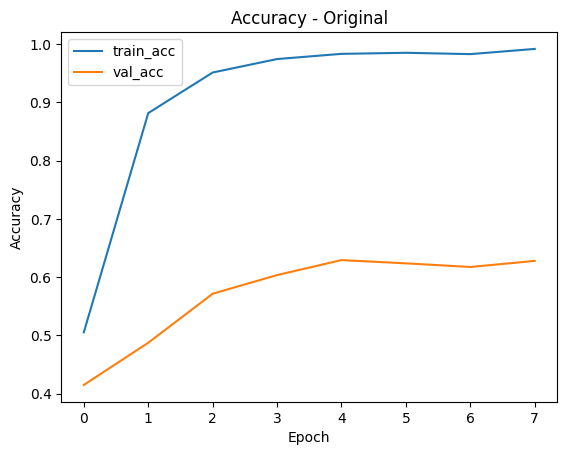

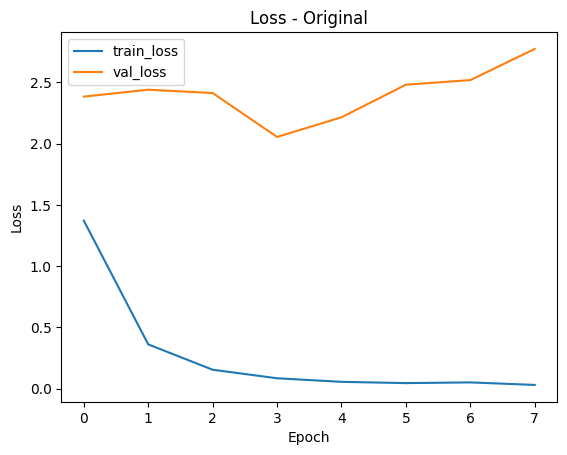

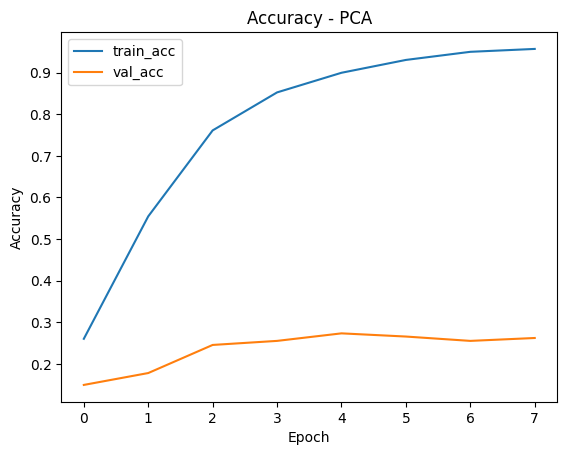

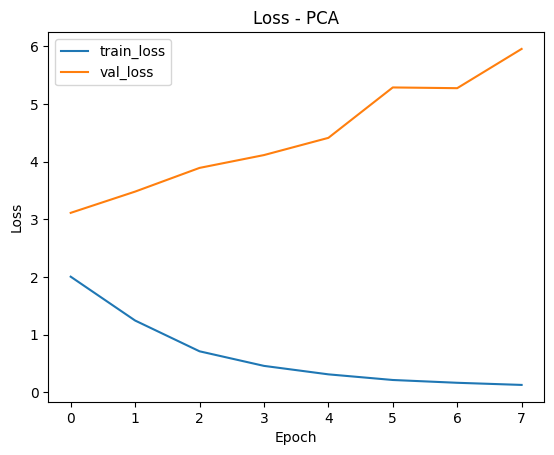

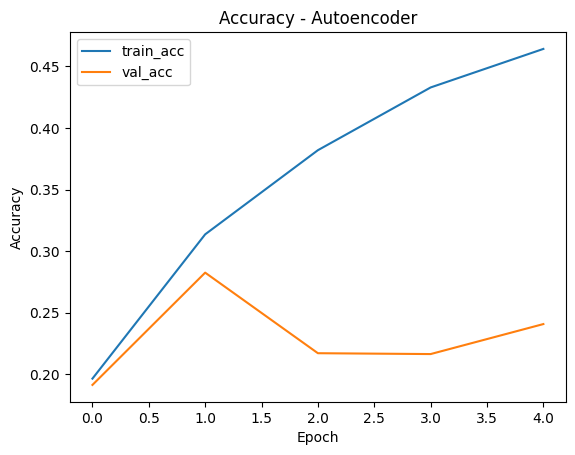

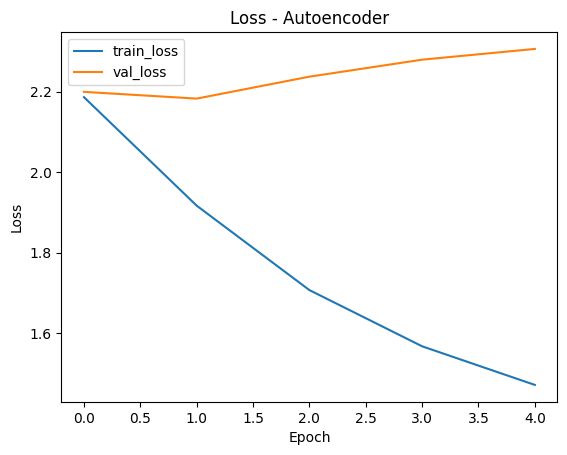

<Figure size 800x800 with 0 Axes>

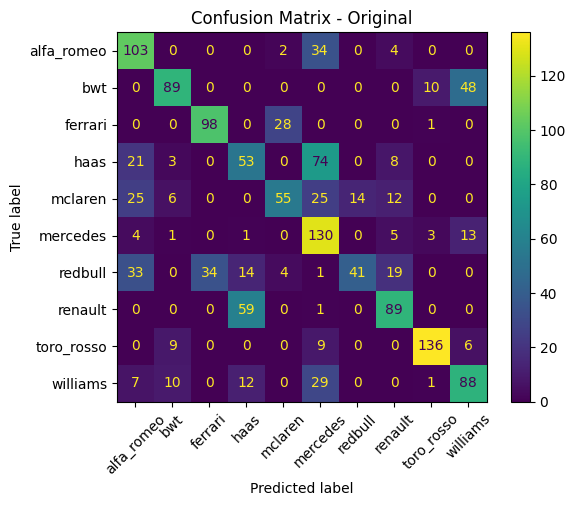

<Figure size 800x800 with 0 Axes>

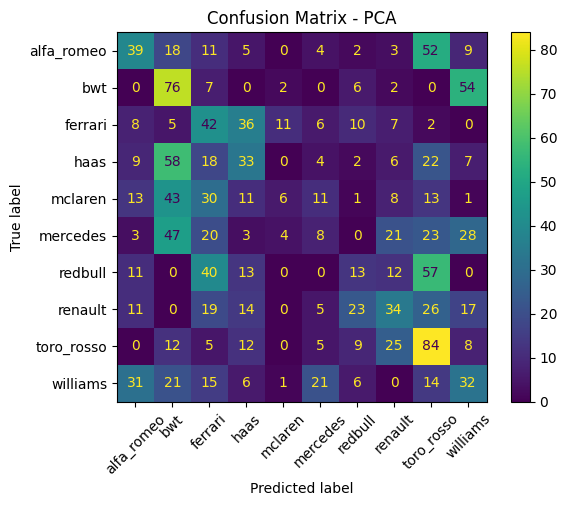

<Figure size 800x800 with 0 Axes>

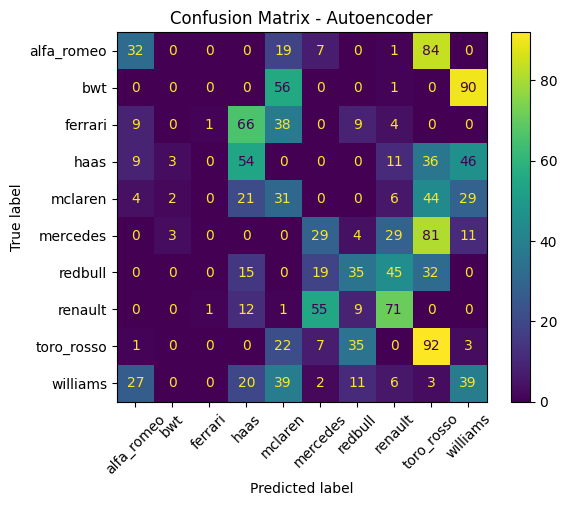

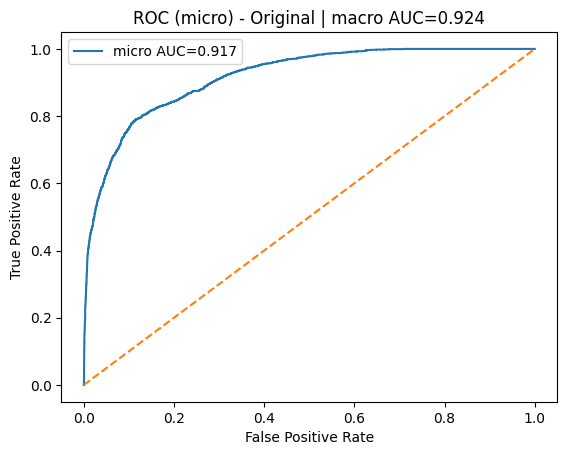

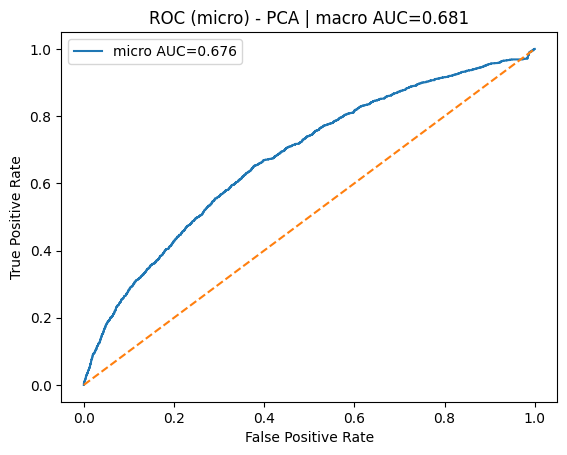

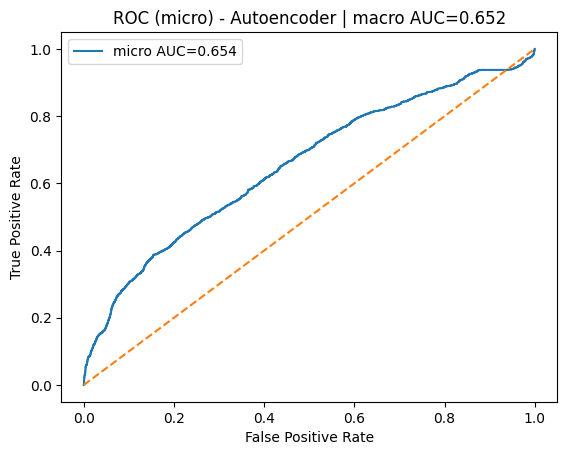

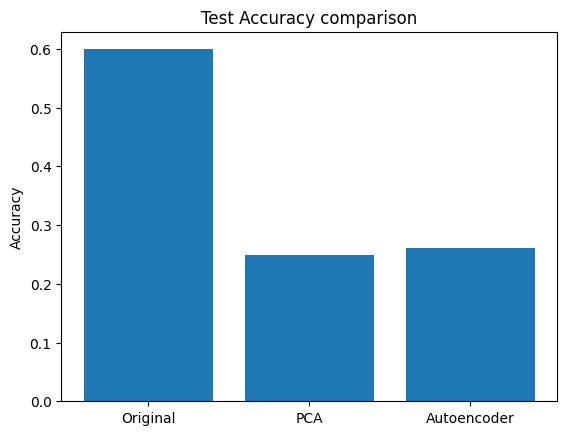

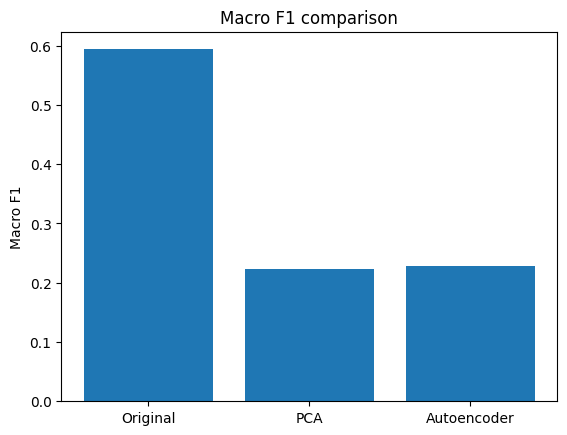

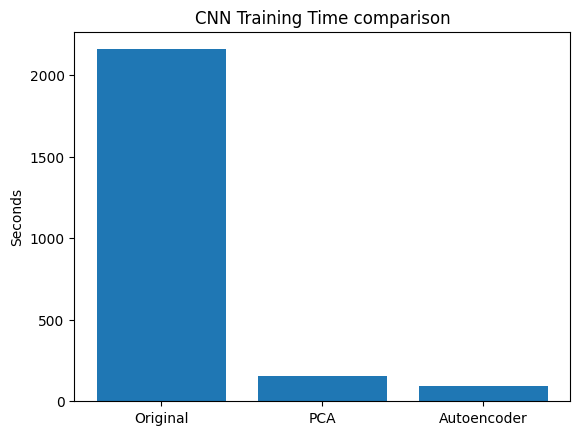

In [ ]:

# Train 3 CNNs
def build_cnn(input_shape, num_classes, base_filters=32, dense_units=128, dropout=0.3, lr=1e-3):
    model = models.Sequential([
        tf.keras.Input(shape=input_shape),

        layers.Conv2D(base_filters, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(base_filters*2, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(base_filters*4, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def train_cnn_fast(X_train, y_train, X_val, y_val, X_test, y_test, input_shape, num_classes, tag=""):
    configs = [
        {"base_filters": 32, "dense_units": 128, "dropout": 0.3, "lr": 1e-3, "batch": 64},
        {"base_filters": 16, "dense_units": 128, "dropout": 0.3, "lr": 1e-3, "batch": 64},
        {"base_filters": 32, "dense_units": 64,  "dropout": 0.4, "lr": 3e-4, "batch": 64},
    ]

    best_cfg, best_val = None, -1
    best_model, best_hist = None, None

    t0 = time.perf_counter()

    for cfg in configs:
        model = build_cnn(
            input_shape=input_shape, num_classes=num_classes,
            base_filters=cfg["base_filters"],
            dense_units=cfg["dense_units"],
            dropout=cfg["dropout"],
            lr=cfg["lr"]
        )
        es = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)

        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=15,
            batch_size=cfg["batch"],
            verbose=0,
            callbacks=[es]
        )
        val_acc = max(hist.history["val_accuracy"])
        print(f"{tag} cfg={cfg} val_acc={val_acc:.4f}")

        if val_acc > best_val:
            best_val = val_acc
            best_cfg = cfg
            best_model = model
            best_hist = hist.history

        tf.keras.backend.clear_session()

    total_time = time.perf_counter() - t0

    y_proba = best_model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "best_cfg": best_cfg,
        "best_val_acc": best_val,
        "training_time_sec": total_time,
        "y_proba": y_proba,
        "y_pred": y_pred
    }

    print(f"\n[{tag}] TEST acc={metrics['accuracy']:.4f} f1_macro={metrics['f1_macro']:.4f} time={total_time:.1f}s")
    return best_model, best_hist, metrics

# Train 3 models
model_orig, hist_orig, metrics_orig = train_cnn_fast(
    X_train_img, y_train, X_val_img, y_val, X_test_img, y_test,
    input_shape=X_train_img.shape[1:], num_classes=num_classes, tag="CNN ORIGINAL"
)

model_pca, hist_pca, metrics_pca = train_cnn_fast(
    X_train_pca_img, y_train, X_val_pca_img, y_val, X_test_pca_img, y_test,
    input_shape=X_train_pca_img.shape[1:], num_classes=num_classes, tag="CNN PCA"
)

model_ae, hist_ae, metrics_ae = train_cnn_fast(
    X_train_ae_img, y_train, X_val_ae_img, y_val, X_test_ae_img, y_test,
    input_shape=X_train_ae_img.shape[1:], num_classes=num_classes, tag="CNN AE"
)


# Evaluation visuals

def plot_learning(history, tag):
    if "accuracy" in history and "val_accuracy" in history:
        plt.figure()
        plt.plot(history["accuracy"], label="train_acc")
        plt.plot(history["val_accuracy"], label="val_acc")
        plt.title(f"Accuracy - {tag}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

    if "loss" in history and "val_loss" in history:
        plt.figure()
        plt.plot(history["loss"], label="train_loss")
        plt.plot(history["val_loss"], label="val_loss")
        plt.title(f"Loss - {tag}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

def plot_cm(cm, class_names, tag):
    plt.figure(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=45, values_format="d")
    plt.title(f"Confusion Matrix - {tag}")
    plt.show()

def plot_micro_roc(y_true, y_proba, num_classes, tag):
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_micro = auc(fpr, tpr)
    auc_macro = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")

    plt.figure()
    plt.plot(fpr, tpr, label=f"micro AUC={auc_micro:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC (micro) - {tag} | macro AUC={auc_macro:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    return auc_micro, auc_macro

# Learning curves
plot_learning(hist_orig, "Original")
plot_learning(hist_pca, "PCA")
plot_learning(hist_ae, "Autoencoder")

# Confusion matrices
plot_cm(metrics_orig["confusion_matrix"], class_names, "Original")
plot_cm(metrics_pca["confusion_matrix"], class_names, "PCA")
plot_cm(metrics_ae["confusion_matrix"], class_names, "Autoencoder")

# ROC-AUC
auc_micro_o, auc_macro_o = plot_micro_roc(y_test, metrics_orig["y_proba"], num_classes, "Original")
auc_micro_p, auc_macro_p = plot_micro_roc(y_test, metrics_pca["y_proba"], num_classes, "PCA")
auc_micro_a, auc_macro_a = plot_micro_roc(y_test, metrics_ae["y_proba"], num_classes, "Autoencoder")

# Comparison bar charts
labels = ["Original", "PCA", "Autoencoder"]
accs  = [metrics_orig["accuracy"], metrics_pca["accuracy"], metrics_ae["accuracy"]]
f1s   = [metrics_orig["f1_macro"], metrics_pca["f1_macro"], metrics_ae["f1_macro"]]
times = [metrics_orig["training_time_sec"], metrics_pca["training_time_sec"], metrics_ae["training_time_sec"]]

plt.figure()
plt.bar(labels, accs)
plt.title("Test Accuracy comparison")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.bar(labels, f1s)
plt.title("Macro F1 comparison")
plt.ylabel("Macro F1")
plt.show()

plt.figure()
plt.bar(labels, times)
plt.title("CNN Training Time comparison")
plt.ylabel("Seconds")
plt.show()
